# Lecture 3: Image sharpening and edge detection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Library imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import exposure
from skimage.filters import threshold_otsu, gaussian, unsharp_mask
from sklearn import cluster
from skimage import data
import os

In [ ]:
print(os.listdir())
os.chdir("drive/MyDrive/NECST/PiA/Lezione3")
print(os.listdir())


['.config', 'drive', 'sample_data']
['Lezione3.ipynb', 'images', 'Lecture3.pptx', 'vessel_detection_results.png', 'retinal_vessel_detection.ipynb']


## Prepare images

In [ ]:
# --- x-ray image ---
xray_path = 'images/chest_xray.png'
img=cv2.imread(xray_path,0) # read image with cv2
image_xray = cv2.normalize(img, None, alpha=0, beta=1.0, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)

# --- square image ---
def generate_square(size=128, box=(32, 32, 96, 96)):
    """Create a square shape on black background; box=(y0, x0, y1, x1)."""
    # create a 3 channel image
    img = np.zeros((size, size), dtype=np.float32)
    y0, x0, y1, x1 = box
    img[y0:y1, x0:x1] = 1.0
    # create a larger box around this first one
    y0, x0, y1, x1 = y0-10, x0-10, y1+10, x1+10


    return img

img_sq = generate_square()

# --- cat image ---

cat_path = 'images/cat.jpg'
img=cv2.imread(cat_path,0) # read image with cv2
image_cat = cv2.normalize(img, None, alpha=0, beta=1.0, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)

eye_img = "images/28_A.png"

eye_img = cv2.imread(eye_img, 0)
eye_img = cv2.normalize(eye_img, None, alpha=0, beta=1.0, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)


In [ ]:
print(type(image_xray))
print(image_xray.dtype)
print(type(img_sq))
print(img_sq.dtype)
print(type(image_cat))
print(image_cat.dtype)
print(type(eye_img))
print(eye_img.dtype)

<class 'numpy.ndarray'>
float32
<class 'numpy.ndarray'>
float32
<class 'numpy.ndarray'>
float32
<class 'numpy.ndarray'>
float32


In [ ]:
print(image_xray.min(), image_xray.max())
print(image_cat.min(), image_cat.max())
print(img_sq.min(), img_sq.max())
print(eye_img.min(), eye_img.max())

0.0 1.0
4.656613e-10 1.0
0.0 1.0
0.0 1.0


## Sharpening

### Unsharp masking

**Unsharp Mask** (USM) is a sharpening technique that can be found already implemented withing skimage:

$$I_{sharp} = I + \alpha \cdot (I - G_{\sigma}(I))$$

where $G_{\sigma}$ is a gaussian filter. The sharpened image is the difference between the original image and its blurred version. This way, high-frequency details are amplified

**Parameters:**
- `radius` (σ): scale of details; how much you are blurring. Controls the scale of the features considered edges. Technically, it represents the σ of the gaussian blur
- `amount` (α): intensity of the sharpening operation. It multiplies the extracted details before adding them back.

Manual implementation of unsharp mask

In [ ]:
def unsharpMask(img, kernel_size=(9, 9), sigma=1.0, amount=1.0):
    """Return a sharpened version of the image, using an unsharp mask."""
    blurred = cv2.GaussianBlur(img, kernel_size, sigma)
    sharpened = float(amount + 1) * img - float(amount) * blurred
    sharpened = np.maximum(sharpened, np.zeros(sharpened.shape))
    sharpened = np.minimum(sharpened, np.ones(sharpened.shape))
    sharpened = sharpened.astype(np.float32)
    return sharpened

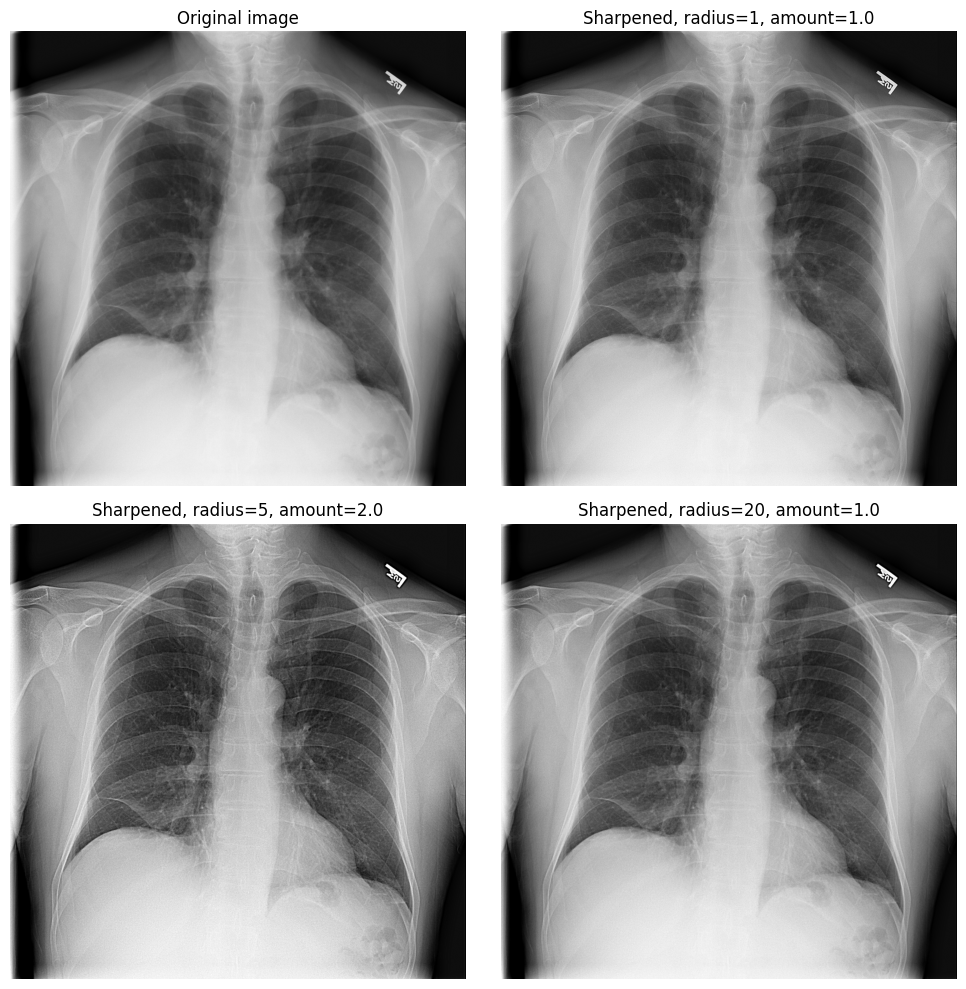

In [ ]:

result_1 = unsharpMask(image_xray, sigma=1, amount=1.0)
result_2 = unsharpMask(image_xray, sigma=5, amount=2.0)
result_3 = unsharpMask(image_xray, sigma=20, amount=1.0)

fig, axes = plt.subplots(nrows=2, ncols=2,
                         sharex=True, sharey=True, figsize=(10, 10))
ax = axes.ravel()

ax[0].imshow(image_xray, cmap=plt.cm.gray)
ax[0].set_title('Original image')

ax[1].imshow(result_1, cmap=plt.cm.gray)
ax[1].set_title('Sharpened, radius=1, amount=1.0')

ax[2].imshow(result_2, cmap=plt.cm.gray)
ax[2].set_title('Sharpened, radius=5, amount=2.0')

ax[3].imshow(result_3, cmap=plt.cm.gray)
ax[3].set_title('Sharpened, radius=20, amount=1.0')

for a in ax:
    a.axis('off')
fig.tight_layout()
plt.show()

With the skimage function ...

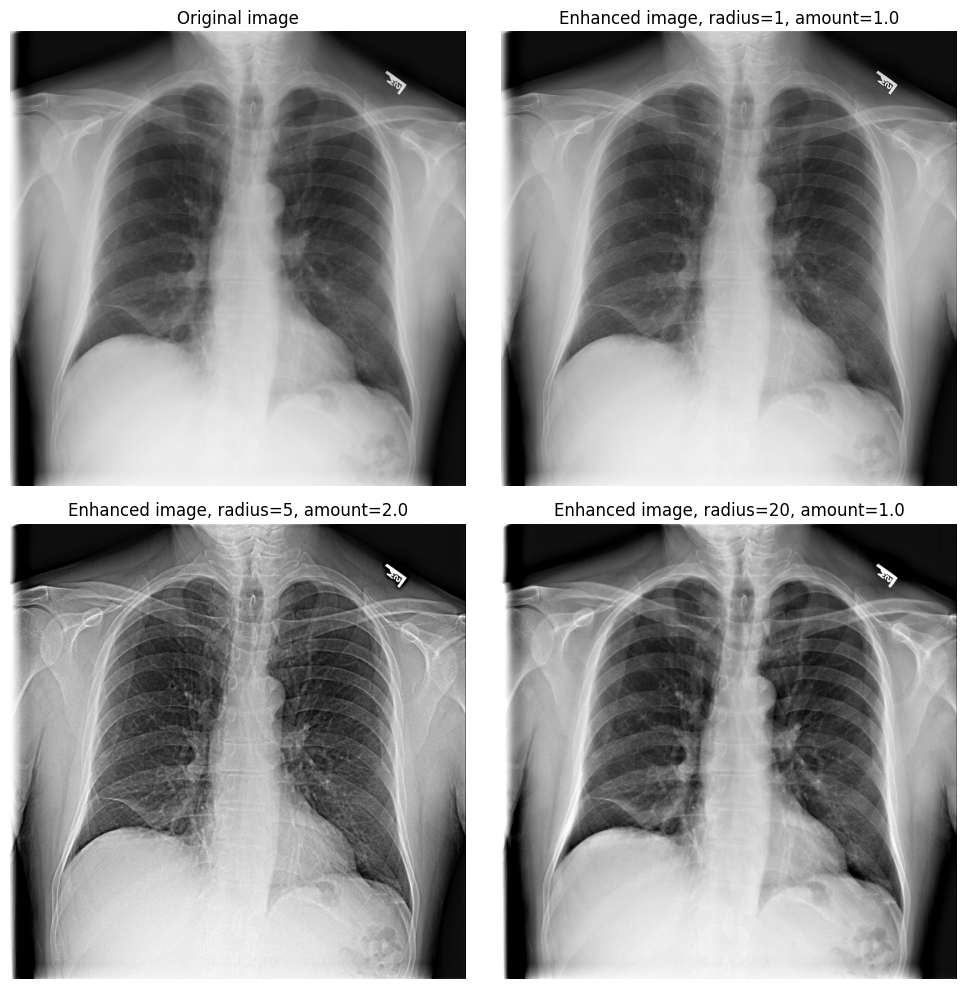

In [ ]:
result_1 = unsharp_mask(image_xray, radius=1, amount=1)
result_2 = unsharp_mask(image_xray, radius=5, amount=2)
result_3 = unsharp_mask(image_xray, radius=20, amount=1)

fig, axes = plt.subplots(nrows=2, ncols=2,
                         sharex=True, sharey=True, figsize=(10, 10))
ax = axes.ravel()

ax[0].imshow(image_xray, cmap=plt.cm.gray)
ax[0].set_title('Original image')
ax[1].imshow(result_1, cmap=plt.cm.gray)
ax[1].set_title('Enhanced image, radius=1, amount=1.0')
ax[2].imshow(result_2, cmap=plt.cm.gray)
ax[2].set_title('Enhanced image, radius=5, amount=2.0')
ax[3].imshow(result_3, cmap=plt.cm.gray)
ax[3].set_title('Enhanced image, radius=20, amount=1.0')

for a in ax:
    a.axis('off')
fig.tight_layout()
plt.show()

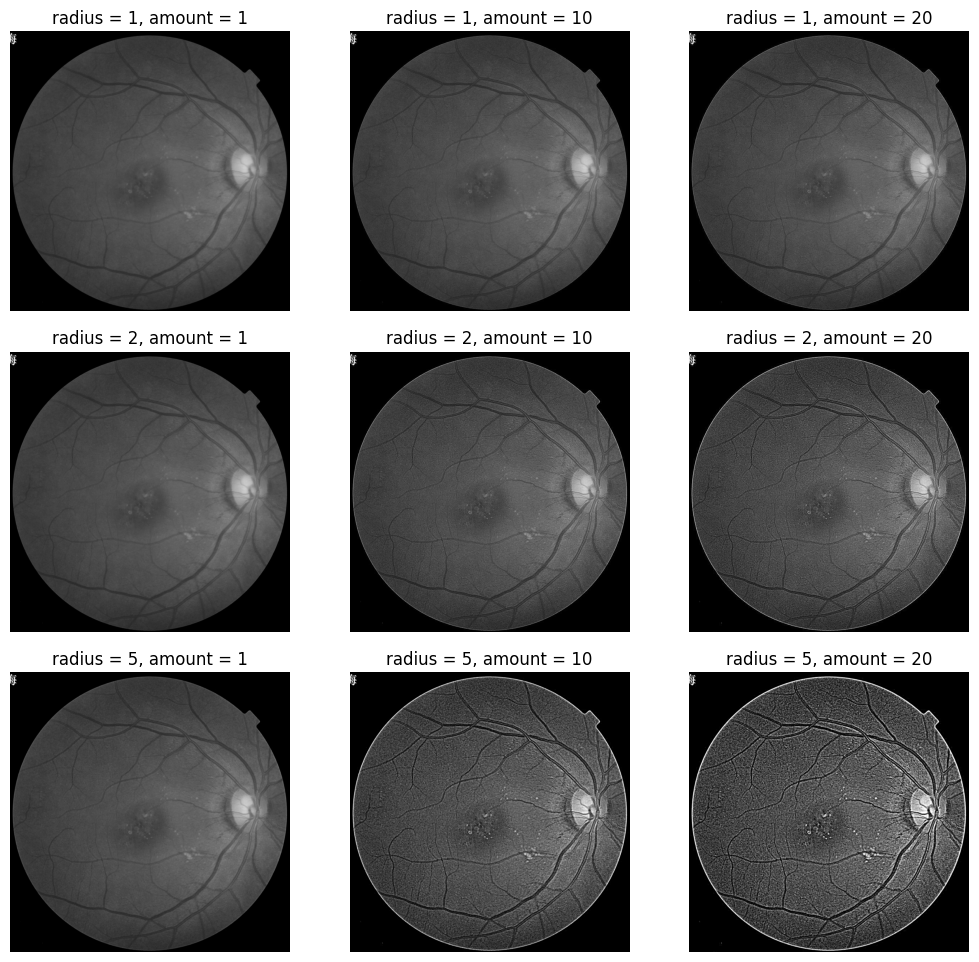

In [ ]:
plt.figure(figsize = (10, 10))
radii = [1, 2, 5]
amounts = [1, 10, 20]
for ii in range(len(radii)):
  for jj in range(len(amounts)):
    radius = radii[ii]
    amount = amounts[jj]
    result = unsharp_mask(eye_img, radius=radius, amount=amount)
    plt.subplot(3, 3, ii*3 + jj + 1)
    plt.imshow(result, cmap = 'gray')
    plt.title(f"radius = {radius}, amount = {amount}")
    plt.tight_layout()
    plt.axis('off')


### High-Boost Spatial Filter (Matrix Form)

The high-boost filter can be expressed using a convolution kernel:

$$
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & x  & -1 \\
-1 & -1 & -1
\end{bmatrix}
=
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & 8  & -1 \\
-1 & -1 & -1
\end{bmatrix}
+
\begin{bmatrix}
0 & 0 & 0 \\
0 & x - 8 & 0 \\
0 & 0 & 0
\end{bmatrix}
$$

- The first matrix is the **Laplacian filter** (high-pass component)
- The second matrix is a **scaled identity kernel**, where:

$$
A = x - 8
$$

\( x \) controls how much of the original image is retained  
- **\( x = 8 \)**  
  - The identity term disappears  
  - Pure **high-pass filtering** (only edges are preserved)

- **\( x > 8 \)**  
  - Adds back part of the original image  
  - **High-boost filtering** (it returns a sharpened image)

- **\( x < 8 \)**  
  - Negative contribution of the original image  
  - Output appears like a **negative / inverted image**


In [ ]:
def high_boost(img, x = 8, stretch = False):
  # create the kernel for applying high-boost filter
  kernel = -1*np.ones((3, 3))
  kernel[1, 1] = x

  res = cv2.filter2D(img, -1, kernel)
  if stretch:
    norm_image = cv2.normalize(res, None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX, dtype = cv2.CV_8UC1)
    #out = cv2.equalizeHist(norm_image)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    out = clahe.apply(norm_image)
  else:
    out = res
  return out


In [ ]:
values = [6, 7, 8, 9, 10, 11]
outs = []
for value in values:
  out = high_boost(image_xray, value)
  outs.append(out)

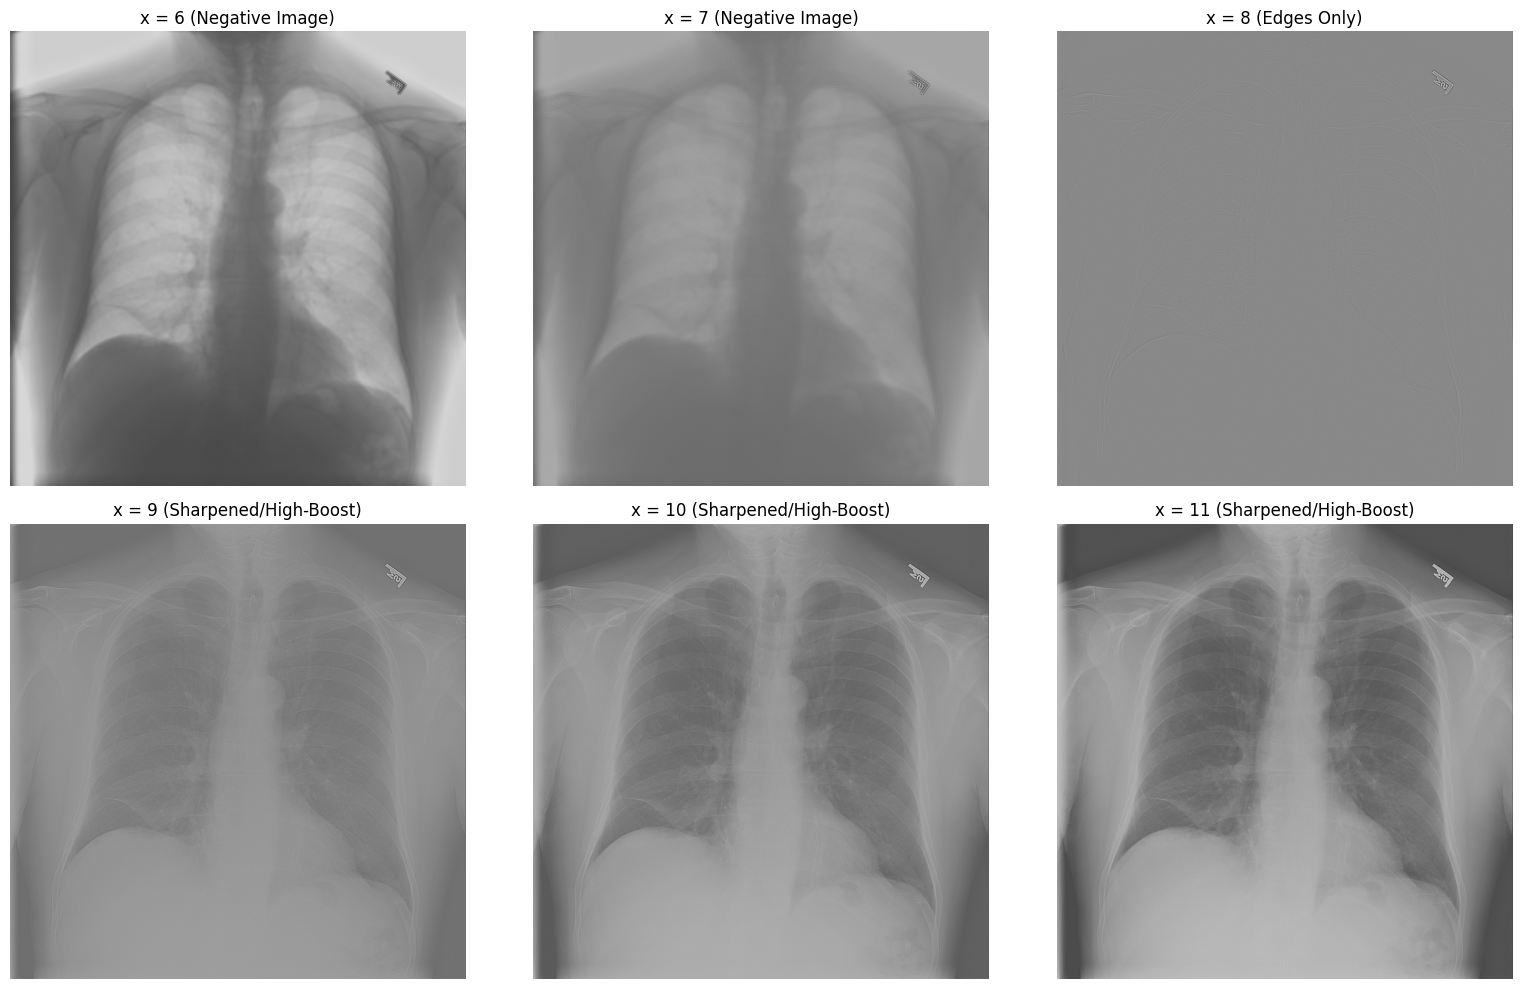

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

ax = axes.ravel()

for i in range(len(values)):
    val = values[i]
    out_image = outs[i]

    # Determine the title based on the 'x' value
    if val < 8:
        title = f'x = {val} (Negative Image)'
    elif val == 8:
        title = f'x = {val} (Edges Only)'
    else: # val > 8
        title = f'x = {val} (Sharpened/High-Boost)'

    # Plot the image
    ax[i].imshow(out_image, cmap='gray')
    ax[i].set_title(title)
    ax[i].axis('off')

plt.tight_layout()
plt.show()

We can now try strecthing the histogram

In [ ]:
values = [6, 7, 8, 9, 10, 11]
outs = []
for value in values:
  out = high_boost(image_xray, value, stretch = True)
  outs.append(out)

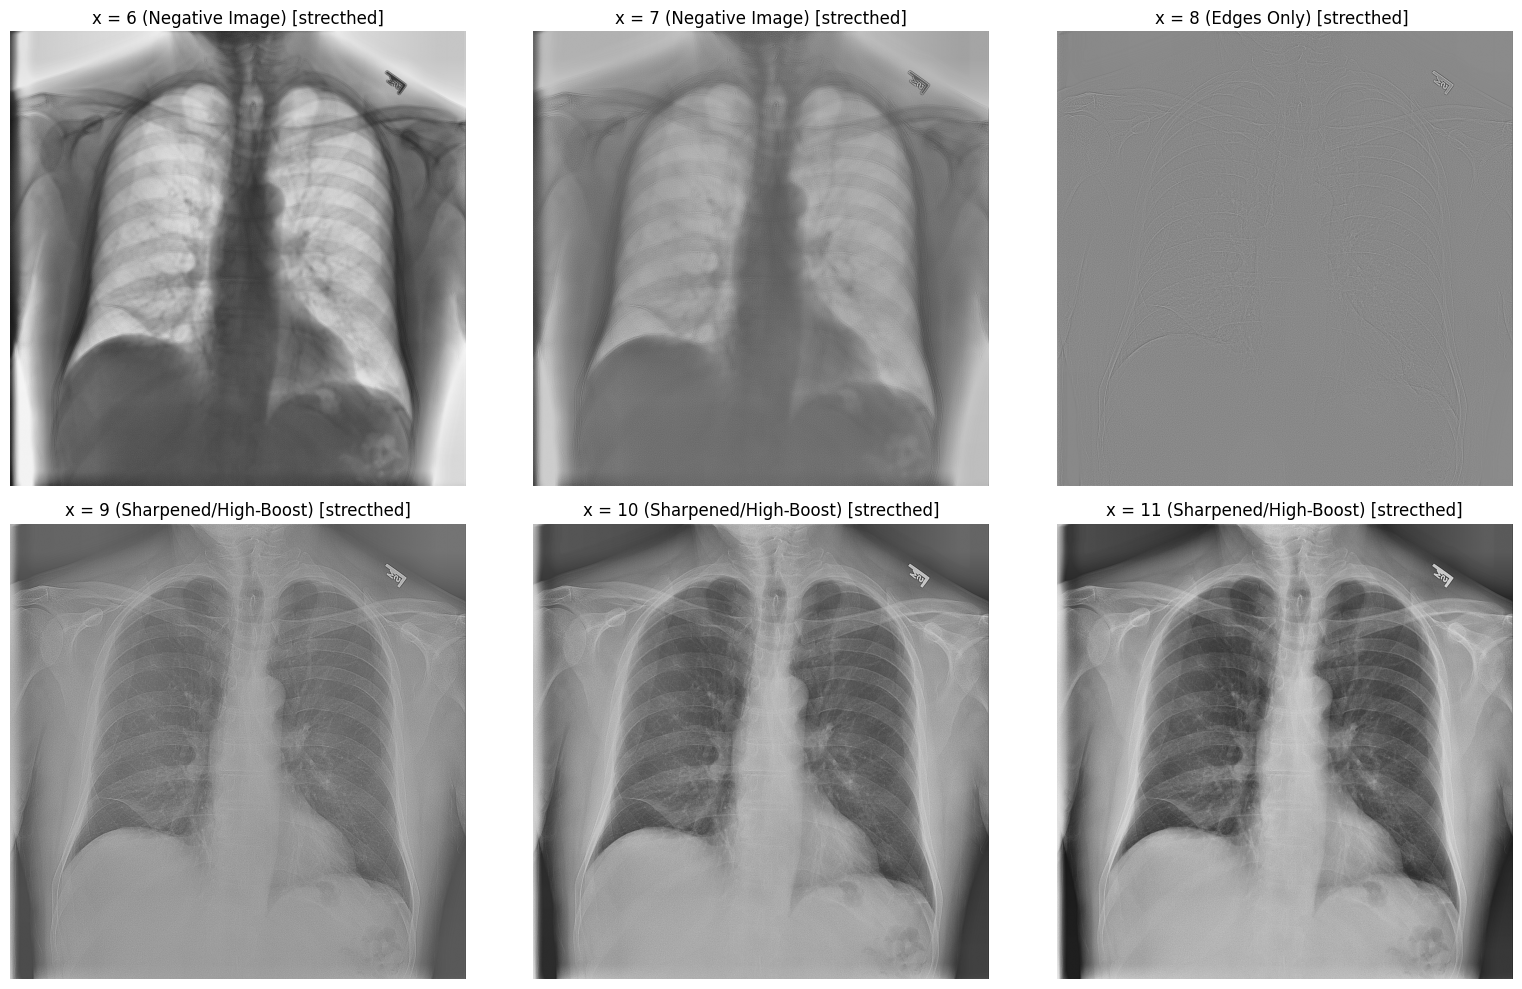

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))

ax = axes.ravel()

for i in range(len(values)):
    val = values[i]
    out_image = outs[i]

    # Determine the title based on the 'x' value
    if val < 8:
        title = f'x = {val} (Negative Image) [strecthed]'
    elif val == 8:
        title = f'x = {val} (Edges Only) [strecthed] '
    else: # val > 8
        title = f'x = {val} (Sharpened/High-Boost) [strecthed]'

    # Plot the image
    ax[i].imshow(out_image, cmap='gray')
    ax[i].set_title(title)
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# try it for the image with the eye and the image for the cat!!!




## Edge detection

### Gradient operators: Sobel, Prewitt and Roberts

The **Sobel filter** computes the spatial gradient of the image, highlighting intensity transitions (= vessel edges):

$$
G_x = \begin{bmatrix}
-1 & 0 & +1 \\
-2 & 0 & +2 \\
-1 & 0 & +1
\end{bmatrix} * I
\qquad
G_y = \begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
+1 & +2 & +1
\end{bmatrix} * I
$$

$$
|G| = \sqrt{G_x^2 + G_y^2}
$$

It is useful for detecting both horizontal and vertical edges of vessels.

---

### Prewitt Filter

The **Prewitt filter** computes the spatial gradient of the image using simpler kernels:

$$
G_x = \begin{bmatrix}
-1 & 0 & +1 \\
-1 & 0 & +1 \\
-1 & 0 & +1
\end{bmatrix} * I
\qquad
G_y = \begin{bmatrix}
-1 & -1 & -1 \\
0 & 0 & 0 \\
+1 & +1 & +1
\end{bmatrix} * I
$$

$$
|G| = \sqrt{G_x^2 + G_y^2}
$$

It is useful for detecting horizontal and vertical edges, with less smoothing compared to Sobel.


---

### Roberts Filter

The **Roberts filter** computes the spatial gradient using diagonal differences

$$
G_x = \begin{bmatrix}
+1 & 0 \\
0 & -1
\end{bmatrix} * I
\qquad
G_y = \begin{bmatrix}
0 & +1 \\
-1 & 0
\end{bmatrix} * I
$$

$$
|G| = \sqrt{G_x^2 + G_y^2}
$$

It is useful for detecting diagonal edges and very fine structures, but is more sensitive to noise.

In [ ]:
def apply_filters(img):
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_f = img.astype(np.float32)

    # --- SOBEL ---
    kx = np.array([[-1,-2,-1],
                   [0,0,0],
                   [1,2,1]], dtype=np.float32)
    ky = np.array([[-1,0,1],
                   [-2,0,2],
                   [-1,0,1]], dtype=np.float32)
    sobelx = cv2.filter2D(img_f, cv2.CV_32F, kx, borderType=cv2.BORDER_DEFAULT)
    sobely = cv2.filter2D(img_f, cv2.CV_32F, ky, borderType=cv2.BORDER_DEFAULT)


    # --- PREWITT ---
    kx = np.array([[-1, 0, 1],
                   [-1, 0, 1],
                   [-1, 0, 1]], dtype=np.float32)
    ky = np.array([[-1, -1, -1],
                   [ 0,  0,  0],
                   [ 1,  1,  1]], dtype=np.float32)
    prewittx = cv2.filter2D(img_f, cv2.CV_32F, kx, borderType=cv2.BORDER_DEFAULT)
    prewitty = cv2.filter2D(img_f, cv2.CV_32F, ky, borderType=cv2.BORDER_DEFAULT)

    # --- ROBERTS ---
    rx = np.array([[1, 0],
                   [0,-1]], dtype=np.float32)
    ry = np.array([[0, 1],
                   [-1,0]], dtype=np.float32)
    robertsx = cv2.filter2D(img_f, cv2.CV_32F, rx, borderType=cv2.BORDER_DEFAULT)
    robertsy = cv2.filter2D(img_f, cv2.CV_32F, ry, borderType=cv2.BORDER_DEFAULT)

    # --- LAPLACIAN ---
    laplacian = cv2.Laplacian(img_f, cv2.CV_32F, ksize=3, borderType=cv2.BORDER_DEFAULT)

  # for visualization
    def to_u8(a):
        return cv2.normalize(np.abs(a), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    results = {
        'sobel':   {'x': to_u8(sobelx), 'y': to_u8(sobely)},
        'prewitt': {'x': to_u8(prewittx), 'y': to_u8(prewitty)},
        'roberts': {'x': to_u8(robertsx), 'y': to_u8(robertsy)},
        'laplacian_abs': to_u8(laplacian),
    }

    return results


In [ ]:
eye_filters = apply_filters(eye_img)
x_ray_filters = apply_filters(image_xray)
cat_filters = apply_filters(image_cat)
square_filters = apply_filters(img_sq)

In [ ]:
print(eye_filters.keys())

dict_keys(['sobel', 'prewitt', 'roberts', 'laplacian_abs'])


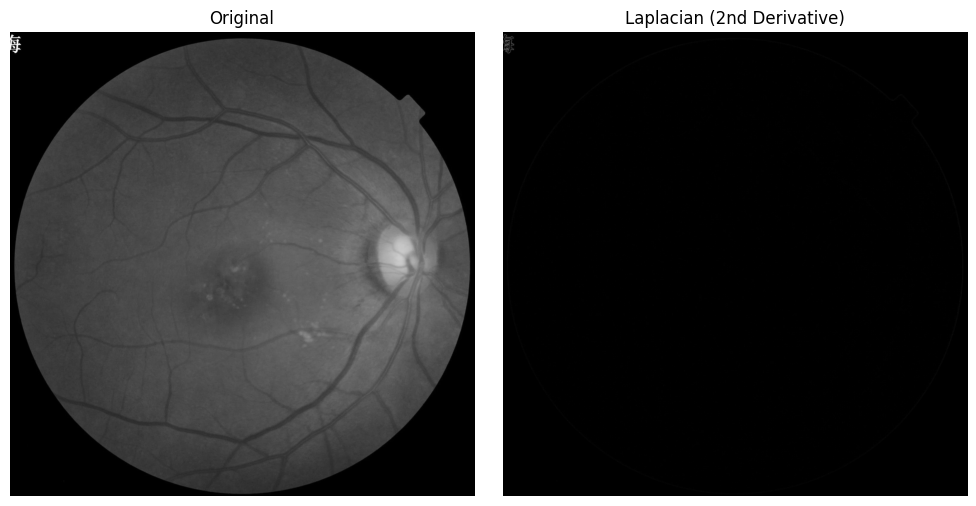

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(eye_img, cmap='gray')
ax1.set_title("Original")
ax1.axis('off')

# Usa la versione uint8 per visualizzare in modo coerente
ax2.imshow(eye_filters['laplacian_abs'], cmap='gray')
ax2.set_title("Laplacian (2nd Derivative)")
ax2.axis('off')

plt.tight_layout()
plt.show()


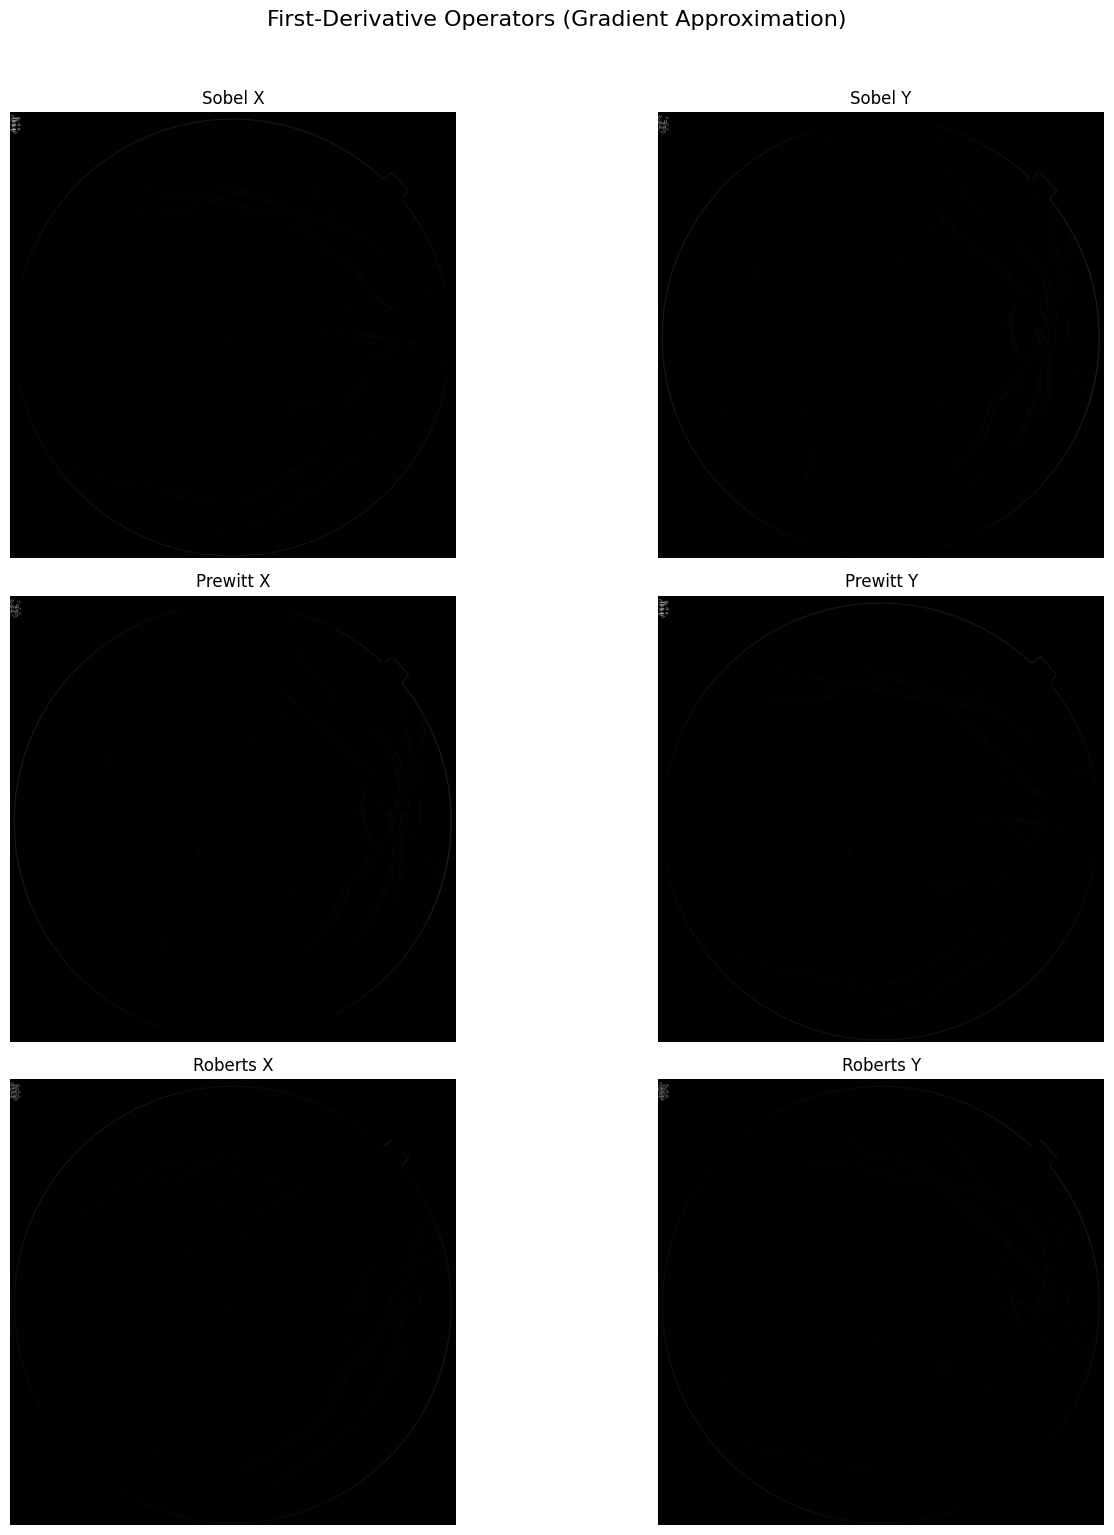

In [ ]:

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plt.suptitle("First-Derivative Operators (Gradient Approximation)", fontsize=16, y=1.02)

# --- Sobel Operator ---
axes[0, 0].imshow(eye_filters['sobel']['x'], cmap='gray')
axes[0, 0].set_title("Sobel X")

axes[0, 1].imshow(eye_filters['sobel']['y'], cmap='gray')
axes[0, 1].set_title("Sobel Y")

# --- Prewitt Operator ---
axes[1, 0].imshow(eye_filters['prewitt']['x'], cmap='gray')
axes[1, 0].set_title("Prewitt X")

axes[1, 1].imshow(eye_filters['prewitt']['y'], cmap='gray')
axes[1, 1].set_title("Prewitt Y")

# --- Roberts Operator ---
axes[2, 0].imshow(eye_filters['roberts']['x'], cmap='gray')
axes[2, 0].set_title("Roberts X")

axes[2, 1].imshow(eye_filters['roberts']['y'], cmap='gray')
axes[2, 1].set_title("Roberts Y")

# Clean up all axes
for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()


# try for square

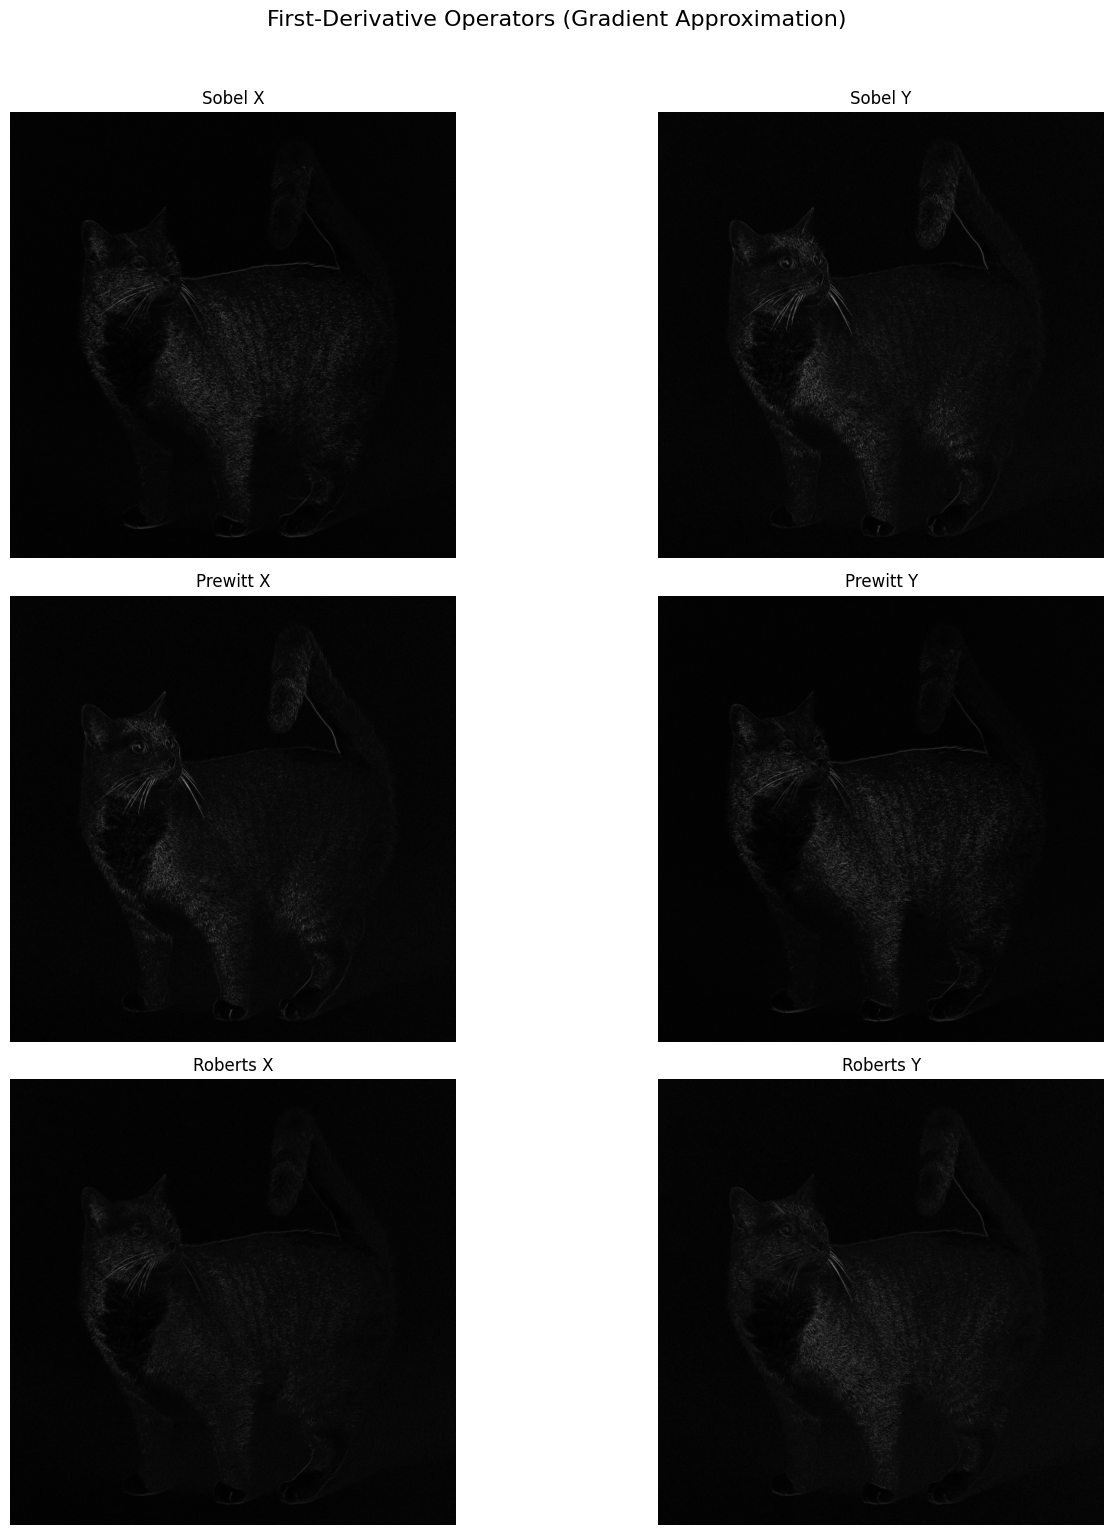

In [ ]:

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
plt.suptitle("First-Derivative Operators (Gradient Approximation)", fontsize=16, y=1.02)

# --- Row 1: Sobel Operator ---
axes[0, 0].imshow(cat_filters['sobel']['x'], cmap='gray')
axes[0, 0].set_title("Sobel X")

axes[0, 1].imshow(cat_filters['sobel']['y'], cmap='gray')
axes[0, 1].set_title("Sobel Y")

# --- Row 2: Prewitt Operator ---
axes[1, 0].imshow(cat_filters['prewitt']['x'], cmap='gray')
axes[1, 0].set_title("Prewitt X")

axes[1, 1].imshow(cat_filters['prewitt']['y'], cmap='gray')
axes[1, 1].set_title("Prewitt Y")

# --- Row 3: Roberts Operator ---
axes[2, 0].imshow(cat_filters['roberts']['x'], cmap='gray')
axes[2, 0].set_title("Roberts X")

axes[2, 1].imshow(cat_filters['roberts']['y'], cmap='gray')
axes[2, 1].set_title("Roberts Y")

# Clean up all axes
for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

### Boxcar operators

In [ ]:
image_xray_int = image_xray*255
image_xray_int = image_xray_int.astype(np.uint8)

image_cat_int = image_cat*255
image_cat_int = image_cat_int.astype(np.uint8)

img_sq_int = img_sq*255
img_sq_int = img_sq_int.astype(np.uint8)

img_eye_int = eye_img * 255
img_eye_int = img_eye_int.astype(np.uint8)

In [ ]:
def build_boxcar(SIZE):
  if SIZE % 2 == 0:
      raise ValueError("Kernel size must be an odd number")
  if SIZE == 3:
    raise ValueError("Kernel size must be greater than 3 (this is a standard Sobel filter)")
  kernel = np.zeros((SIZE,SIZE))
  MAX_ROW = SIZE - 1
  for j in range(SIZE):
    if j == int(np.floor(SIZE/2)):
      kernel[:,j] = 0
    elif j < int(np.floor(SIZE/2)):
      kernel[:,j] = 1
    else: kernel[:,j] = -1

  for j in range(int(np.floor(SIZE/2))):
    max_val = j + 1
    ROW_MAX_VAL_START = j  # we select the row from which the current maximum number will start
    ROW_END = MAX_ROW - ROW_MAX_VAL_START # define where the max val ends
    kernel[ROW_MAX_VAL_START:ROW_END+1, j] = int(max_val)
    counter = 1

    # now we add other number in decreasing order, until we reach 1
    for n in range(max_val-1, 1, -1):
      kernel[ROW_MAX_VAL_START-counter, j] = int(n)
      kernel[ROW_END+counter, j] = int(n)
      counter += 1

  # starting from j = int(np.floor(size/2)), we take the mirror of the first half, but changed of sign
  kernel[:,int(np.floor(SIZE/2)) + 1:] = -kernel[:,:int(np.floor(SIZE/2))][:,::-1]
  kernel = kernel.astype(int)
  return kernel

In [ ]:
k5 = build_boxcar(5)
k7 = build_boxcar(7)
k9 = build_boxcar(9)

In [ ]:
print("--- kernel 5x5 ---")
print(k5)

print("--- kernel 7x7 ---")
print(k7)

print("--- kernel 9x9 ---")
print(k9)


--- kernel 5x5 ---
[[ 1  1  0 -1 -1]
 [ 1  2  0 -2 -1]
 [ 1  2  0 -2 -1]
 [ 1  2  0 -2 -1]
 [ 1  1  0 -1 -1]]
--- kernel 7x7 ---
[[ 1  1  1  0 -1 -1 -1]
 [ 1  2  2  0 -2 -2 -1]
 [ 1  2  3  0 -3 -2 -1]
 [ 1  2  3  0 -3 -2 -1]
 [ 1  2  3  0 -3 -2 -1]
 [ 1  2  2  0 -2 -2 -1]
 [ 1  1  1  0 -1 -1 -1]]
--- kernel 9x9 ---
[[ 1  1  1  1  0 -1 -1 -1 -1]
 [ 1  2  2  2  0 -2 -2 -2 -1]
 [ 1  2  3  3  0 -3 -3 -2 -1]
 [ 1  2  3  4  0 -4 -3 -2 -1]
 [ 1  2  3  4  0 -4 -3 -2 -1]
 [ 1  2  3  4  0 -4 -3 -2 -1]
 [ 1  2  3  3  0 -3 -3 -2 -1]
 [ 1  2  2  2  0 -2 -2 -2 -1]
 [ 1  1  1  1  0 -1 -1 -1 -1]]


<class 'numpy.ndarray'>
<built-in method astype of numpy.ndarray object at 0x7f671b870810>
<class 'numpy.ndarray'>
<built-in method astype of numpy.ndarray object at 0x7f6728a52910>
<class 'numpy.ndarray'>
<built-in method astype of numpy.ndarray object at 0x7f6728a53db0>


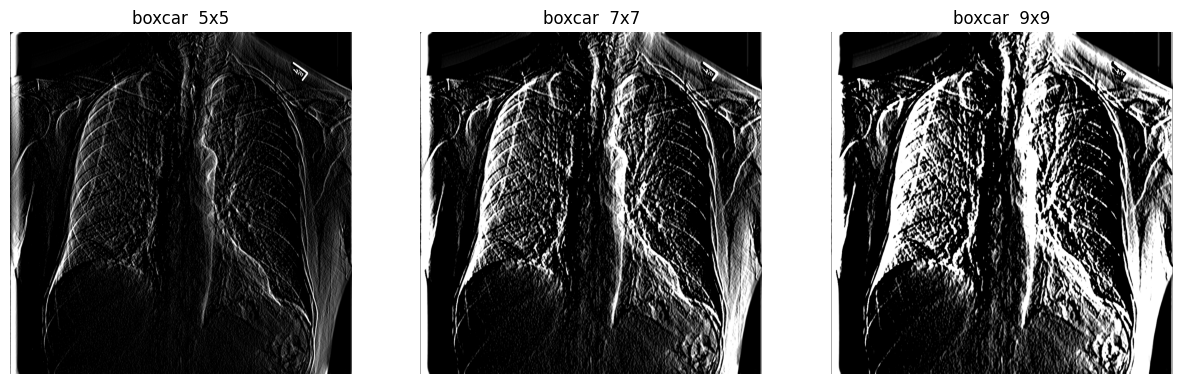

In [ ]:
sizes = [5, 7, 9]
kernels = [k5, k7, k9]
responses = []

for i in range(len(kernels)):
    kx = kernels[i]
    resp = cv2.filter2D(image_xray_int, -1, kx)
    print(type(resp))
    print(resp.astype)
    responses.append((resp))

plt.figure(figsize=(15,5))
for i, r in enumerate(responses):
    s = sizes[i]
    plt.subplot(1,3,i+1)
    plt.title(f"boxcar  {s}x{s}")
    plt.imshow(r, cmap='gray')  #
    plt.axis('off')
plt.show()

### Robinson compass masks

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

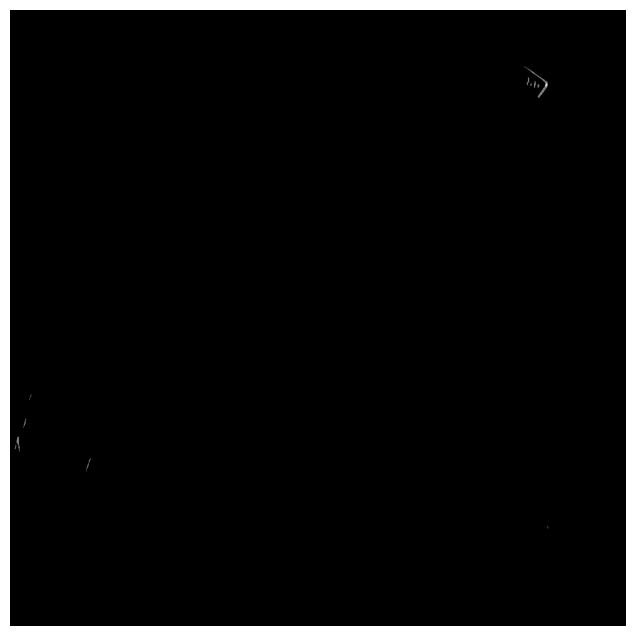

In [ ]:
from scipy import ndimage
from math import pi
from skimage import util

h0_3 = np.array([
    [[-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]],

    [[-2, -1, 0],
    [-1, 0, 1],
    [0, 1, 2]],

    [[-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]],

    [[0, -1, -2],
    [1, 0, -1],
    [2, 1, 0]]
])

h4_7 = np.negative(h0_3)
e_k = np.zeros(image_xray_int.shape)

h0_7 = np.concatenate((h0_3, h4_7), axis=0)

for filter in h0_7:
    e_k = np.maximum(cv2.filter2D(image_xray_int, -1, k7.astype('float32')/255), e_k)


k_k = image_xray_int
for v in range(0, image_xray_int.shape[1]):
    for u in range(0, image_xray_int.shape[0]):
        k_k[u][v] = e_k[u][v]
plt.rcParams["figure.figsize"] = (8,8)
plt.imshow (k_k, cmap = 'gray')
plt.axis("off")

### Laplacian of Gaussian

In [ ]:
LoG_kernel = np.array([
                        [0, 0,  1, 0, 0],
                        [0, 1,  2, 1, 0],
                        [1, 2,-16, 2, 1],
                        [0, 1,  2, 1, 0],
                        [0, 0,  1, 0, 0]
                    ])

(np.float64(-0.5), np.float64(3431.5), np.float64(3431.5), np.float64(-0.5))

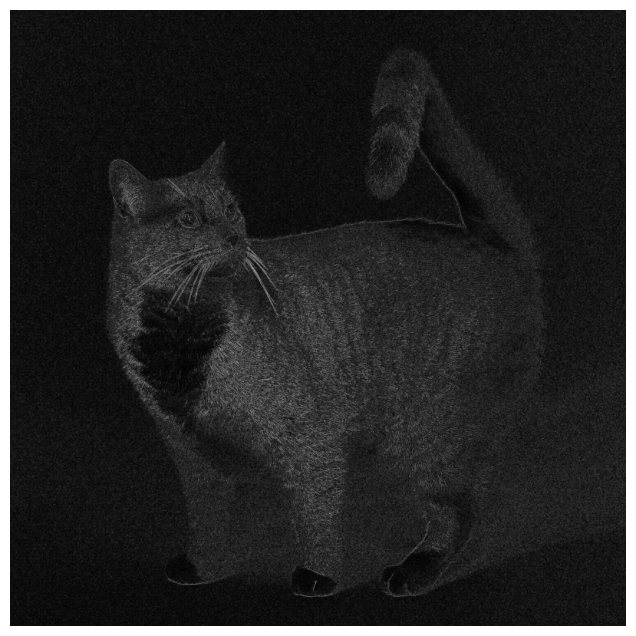

In [ ]:
dog_img = cv2.filter2D(image_cat_int, -1, LoG_kernel)/255
plt.rcParams["figure.figsize"] = (8,8)
plt.imshow (dog_img, cmap = 'gray')
plt.axis("off")

# Canny edge detector

The **Canny edge detector** is a multi-stage algorithm that detects edges with lower noise sensitivity with respect to others edge detectors such as Laplacian
 ### How it works

1. **Noise Reduction (Gaussian Blur)**  

2. **Gradient Computation**  
   Intensity gradients are computed (using a derivative approximator, such as Soble):
   $$
   G = \sqrt{G_x^2 + G_y^2}, \qquad
   \theta = \arctan\left(\frac{G_y}{G_x}\right)
   $$
   - \(G\): edge strength  
   - θ: edge direction

3. **Non-Maximum Suppression**  
   - After getting gradient magnitude and direction, a full scan of image is done to remove any unwanted pixels which may not constitute the edge. For this, at every pixel, pixel is checked if it is a local maximum in its neighborhood in the direction of gradient
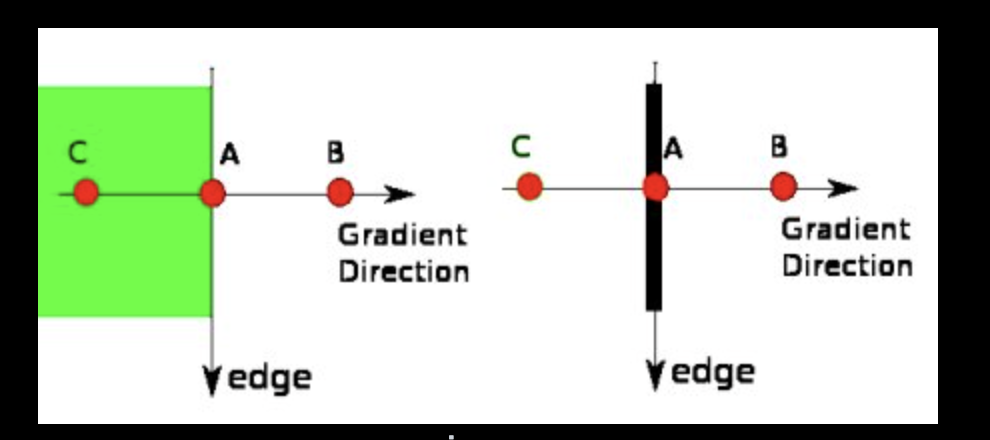

Point A is on the edge ( in vertical direction). Gradient direction is normal to the edge. Point B and C are in gradient directions. So point A is checked with point B and C to see if it forms a local maximum. If so, it is considered for next stage, otherwise, it is suppressed ( put to zero)

4. **Hysteresis Thresholding**  
   Two thresholds are applied:
   - \(T_{high}\): strong edges  
   - \(T_{low}\): weak edges  

   Classification:
   - \(G > T_{high}\) → strong  
   - \(T_{low} < G < T_{high}\) → weak  
   - \(G < T_{low}\)
   - Keep weak edges **only if connected to strong edges**  
   - Remove isolated weak responses  

In [ ]:
xray_path = 'images/hand-x-ray.jpeg'
img=cv2.imread(xray_path,0)
image_hand = cv2.normalize(img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
canny_edge = cv2.Canny(image_hand, 170, 250)

In [ ]:
images = [image_cat_int,
img_sq_int,
image_hand,
img_eye_int
]

In [ ]:
edges = []
for img in images:
  canny_edge = cv2.Canny(img, 120, 220)
  edges.append(canny_edge)


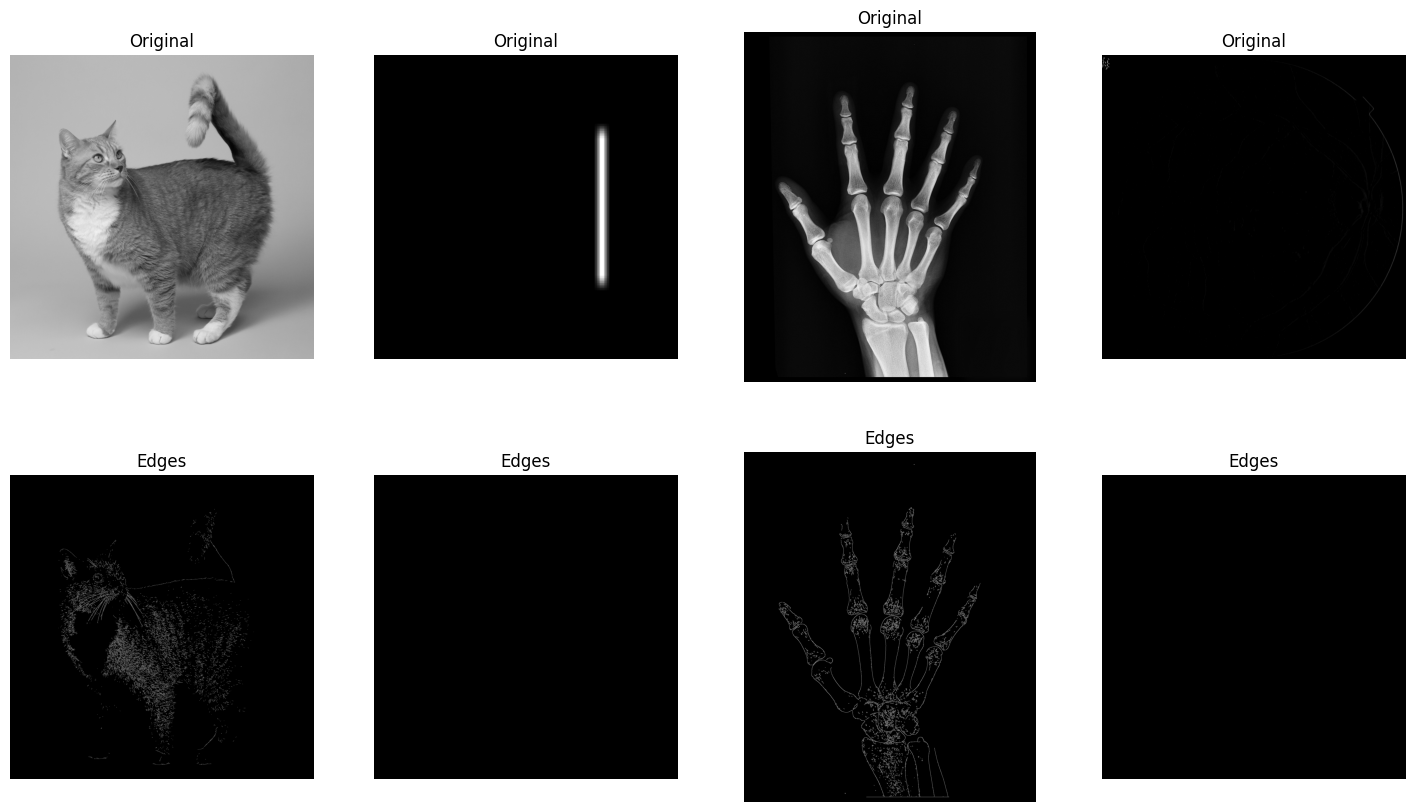

In [ ]:
plt.figure(figsize = (18, 10))
plt.subplot(2, 4, 1)
plt.imshow(images[0], cmap='gray')
plt.axis("off")
plt.title("Original")
plt.subplot(2, 4, 2)
plt.imshow(images[1], cmap='gray')
plt.axis("off")
plt.title("Original")
plt.subplot(2, 4, 3)
plt.imshow(images[2], cmap='gray')
plt.axis("off")
plt.title("Original")
plt.subplot(2, 4, 4)
plt.imshow(images[3], cmap='gray')
plt.axis("off")
plt.title("Original")

plt.subplot(2, 4, 5)
plt.imshow(edges[0], cmap='gray')
plt.axis("off")
plt.title("Edges")
plt.subplot(2, 4, 6)
plt.imshow(edges[1], cmap='gray')
plt.axis("off")
plt.title("Edges")
plt.subplot(2, 4, 7)
plt.imshow(edges[2], cmap='gray')
plt.axis("off")
plt.title("Edges")
plt.subplot(2, 4, 8)
plt.imshow(edges[3], cmap='gray')
plt.axis("off")
plt.title("Edges")



plt.show()

If we try with some preprocessing before applying Canny...

In [ ]:
def apply_canny_after_blur(image, type = 'gaussian', th_low = 170, th_up = 250):
  if type == 'gaussian':
    # pre-processing with gaussian filter
    gaussian_blur = cv2.GaussianBlur(image, (5,5), 1)
    canny = cv2.Canny(gaussian_blur, th_low, th_up)
  else:
    # pre-processing with mean filter
    mean_blur = cv2.blur(image, (5,5))
    canny = cv2.Canny(mean_blur, th_low, th_up)

  return canny


edges_gaussian = []
for img in images:
  canny_gaussian = apply_canny_after_blur(img, 'gaussian', 120, 220)
  edges_gaussian.append(canny_gaussian)

edges_mean = []
for img in images:
  canny_mean = apply_canny_after_blur(img, 'mean', 120, 220)
  edges_mean.append(canny_mean)


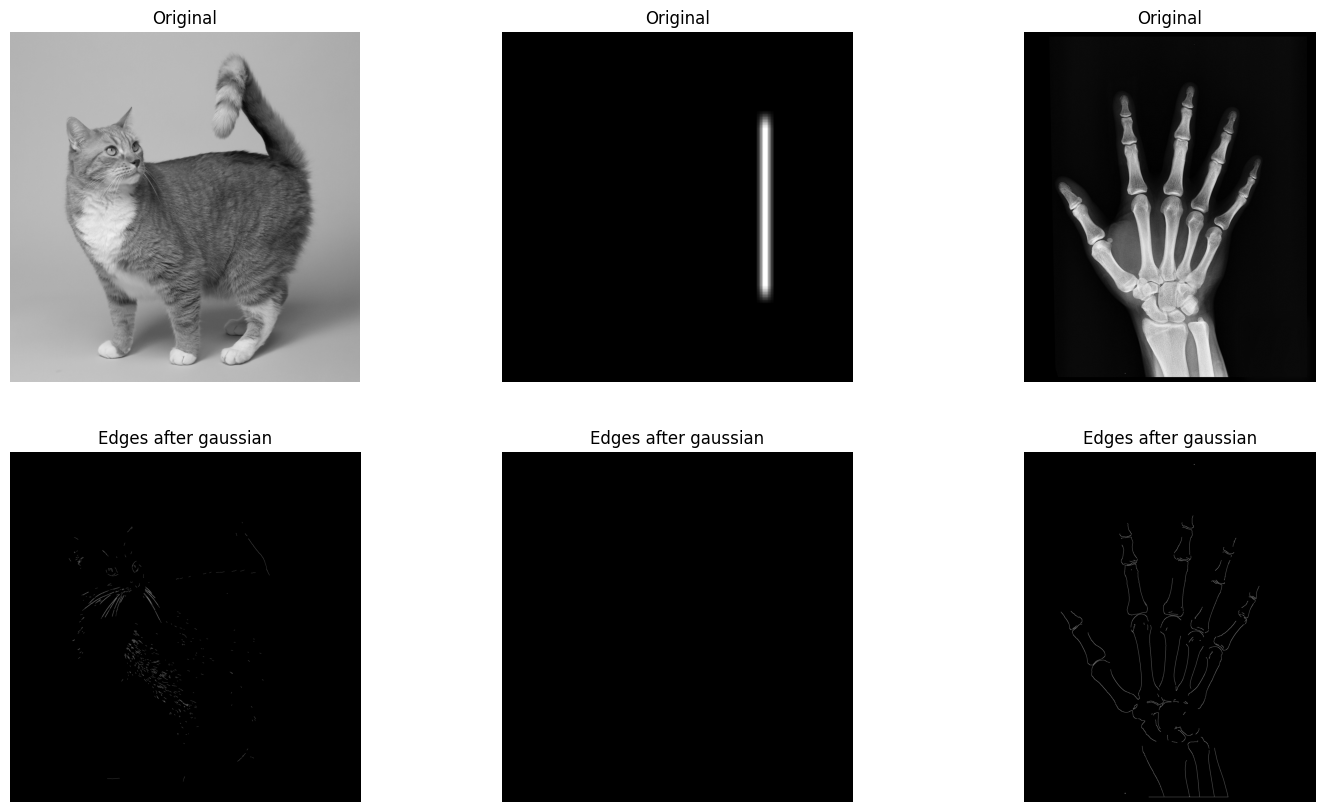

In [ ]:
plt.figure(figsize = (18, 10))
plt.subplot(2, 3, 1)
plt.imshow(images[0], cmap='gray')
plt.axis("off")
plt.title("Original")
plt.subplot(2, 3, 2)
plt.imshow(images[1], cmap='gray')
plt.axis("off")
plt.title("Original")
plt.subplot(2, 3, 3)
plt.imshow(images[2], cmap='gray')
plt.axis("off")
plt.title("Original")

plt.subplot(2, 3, 4)
plt.imshow(edges_gaussian[0], cmap='gray')
plt.axis("off")
plt.title("Edges after gaussian")
plt.subplot(2, 3, 5)
plt.imshow(edges_gaussian[1], cmap='gray')
plt.axis("off")
plt.title("Edges after gaussian")
plt.subplot(2, 3, 6)
plt.imshow(edges_gaussian[2], cmap='gray')
plt.axis("off")
plt.title("Edges after gaussian")



plt.show()

Text(0.5, 1.0, 'Edges after mean')

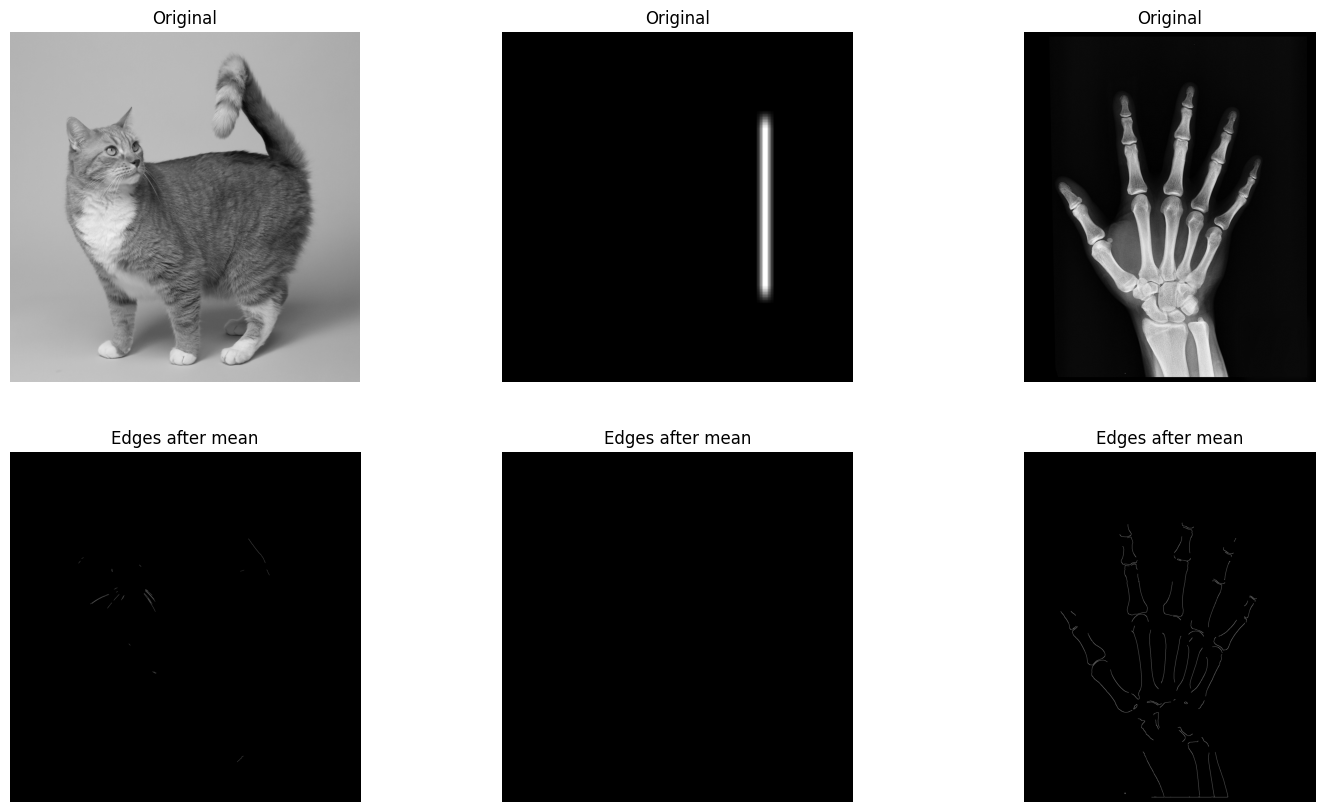

In [ ]:
plt.figure(figsize = (18, 10))
plt.subplot(2, 3, 1)
plt.imshow(images[0], cmap='gray')
plt.axis("off")
plt.title("Original")
plt.subplot(2, 3, 2)
plt.imshow(images[1], cmap='gray')
plt.axis("off")
plt.title("Original")
plt.subplot(2, 3, 3)
plt.imshow(images[2], cmap='gray')
plt.axis("off")
plt.title("Original")

plt.subplot(2, 3, 4)
plt.imshow(edges_mean[0], cmap='gray')
plt.axis("off")
plt.title("Edges after mean")
plt.subplot(2, 3, 5)
plt.imshow(edges_mean[1], cmap='gray')
plt.axis("off")
plt.title("Edges after mean")
plt.subplot(2, 3, 6)
plt.imshow(edges_mean[2], cmap='gray')
plt.axis("off")
plt.title("Edges after mean")


Text(0.5, 1.0, 'Canny + Mean filter')

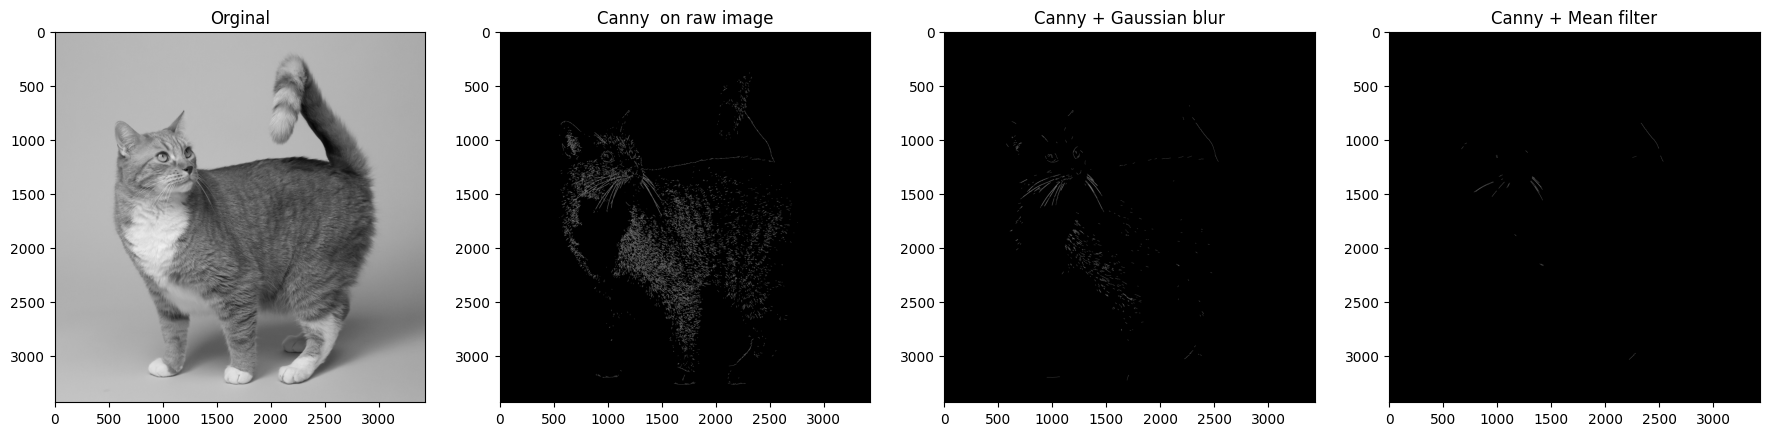

In [ ]:
plt.figure(figsize = (22, 16))

plt.subplot(1, 4, 1)
plt.imshow(images[0], cmap = 'gray')
plt.title("Orginal")

plt.subplot(1, 4, 2)
plt.imshow(edges[0], cmap = 'gray')
plt.title("Canny  on raw image")

plt.subplot(1, 4, 3)
plt.imshow(edges_gaussian[0], cmap = 'gray')
plt.title("Canny + Gaussian blur")

plt.subplot(1, 4, 4)
plt.imshow(edges_mean[0], cmap = 'gray')
plt.title("Canny + Mean filter")
